# XGBoost — COVID-19 Confirmed Cases & Fatality Prediction
## Using Country-Level Health Indicators

**Research Question:** Can confirmed cases and fatalities be predicted using health indicators alongside conventional COVID-19 statistics?

**Approach:** ~70 country-level health indicators (respiratory diseases, hospital density, birth/death rates, etc.) are joined with COVID case data. XGBoost is then used to rank feature importance and generate predictions.

**Key Assumption:** Health indicators alone are expected to have lower importance than early-epidemic case counts (e.g., confirmed cases in first 10 or 50 days). We test this hypothesis through feature importance analysis.


In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


## Utility — RMSLE

Root Mean Squared Logarithmic Error (RMSLE) is used because case counts span orders of magnitude across countries.

In [27]:
def rmsle(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    """Root Mean Squared Logarithmic Error."""
    log_diff = np.log1p(np.maximum(0, y_hat)) - np.log1p(y_true)
    return float(np.sqrt(np.mean(log_diff ** 2)))


## 1. Load & Preprocess Training Data

In [28]:
# Load
train_raw = pd.read_csv('train.csv')
print(f"Raw train shape: {train_raw.shape}")
train_raw.head(5)


Raw train shape: (23562, 6)


,Id,Province_State,Country_Region,Date,ConfirmedCases,Fatalities
0,1,NaN,Afghanistan,2020-01-22,0.0,0.0
1,2,NaN,Afghanistan,2020-01-23,0.0,0.0
2,3,NaN,Afghanistan,2020-01-24,0.0,0.0
3,4,NaN,Afghanistan,2020-01-25,0.0,0.0
4,5,NaN,Afghanistan,2020-01-26,0.0,0.0


In [29]:
# Merge Province_State into Country_Region
train_raw['Country_Region'] = np.where(
    train_raw['Province_State'].isna(),
    train_raw['Country_Region'],
    train_raw['Country_Region'] + '_' + train_raw['Province_State']
)
train_raw.drop(columns='Province_State', inplace=True)

# Ensure cumulative monotonicity
for target_col in ['ConfirmedCases', 'Fatalities']:
    if target_col in train_raw.columns:
        train_raw[target_col] = (
            train_raw.groupby('Country_Region')[target_col].cummax()
        )

# Day-of-year feature
if 'DayOfYear' not in train_raw.columns:
    train_raw['DayOfYear'] = pd.to_datetime(train_raw['Date']).dt.dayofyear

train_raw['Date'] = pd.to_datetime(train_raw['Date']).dt.date

print(f"Processed train shape: {train_raw.shape}")


Processed train shape: (23562, 6)


## 2. Load Health Indicators

In [30]:
health_df = pd.read_csv('country_health_indicators_v3.csv')
print(f"Health indicators shape: {health_df.shape}")


Health indicators shape: (180, 70)


## 3. Merge Datasets

In [31]:
train = pd.merge(train_raw, health_df, on='Country_Region', how='left')
print(f"Merged train shape: {train.shape}")
train.head(3)


Merged train shape: (23562, 75)


,Id,Country_Region,Date,ConfirmedCases,Fatalities,DayOfYear,first_1ConfirmedCases,first_1Fatalities,first_10ConfirmedCases,first_50ConfirmedCases,...,total fertility rate,obesity - adult prevalence rate,school_shutdown_1case,school_shutdown_10case,school_shutdown_50case,school_shutdown_1death,FF_DayOfYear,case1_DayOfYear,case10_DayOfYear,case50_DayOfYear
0,1,Afghanistan,2020-01-22,0.0,0.0,22,2020-02-24,2020-03-22,2020-03-14,2020-03-24,...,4.82,5.5,19.0,-0.0,-10.0,-8.0,82.0,55.0,74.0,84.0
1,2,Afghanistan,2020-01-23,0.0,0.0,23,2020-02-24,2020-03-22,2020-03-14,2020-03-24,...,4.82,5.5,19.0,-0.0,-10.0,-8.0,82.0,55.0,74.0,84.0
2,3,Afghanistan,2020-01-24,0.0,0.0,24,2020-02-24,2020-03-22,2020-03-14,2020-03-24,...,4.82,5.5,19.0,-0.0,-10.0,-8.0,82.0,55.0,74.0,84.0


## 4. XGBoost Model Training

In [32]:
# Columns excluded from features (identifiers, targets, and derived prediction columns)
EXCLUDE_COLS = {
    'ConfirmedCases', 'Country_Region', 'Date', 'Fatalities',
    'Id', 'first_100ConfirmedCases', 'first_10ConfirmedCases',
    'first_1ConfirmedCases', 'first_1Fatalities', 'first_50ConfirmedCases',
    'school_closure', 'yhat_xgb_ConfirmedCases', 'yhat_xgb_Fatalities'
}

feature_cols = list(set(train.columns) - EXCLUDE_COLS)

XGB_PARAMS = dict(
    gamma=0.2,
    learning_rate=0.15,
    n_estimators=100,
    max_depth=11,
    min_child_weight=1,
    nthread=8,
    objective='reg:squarederror'
)

def train_xgb_and_score(df, features, label, params):
    """Fit an XGBRegressor, store predictions in df, return (RMSLE, model)."""
    X_arr = df[features].to_numpy()
    y_arr = df[label].to_numpy()
    model = XGBRegressor(**params)
    model.fit(X_arr, y_arr)
    y_hat = model.predict(X_arr)
    df[f'yhat_xgb_{label}'] = y_hat
    return rmsle(y_arr, y_hat), model

rmsle_confirmed, xgb_confirmed = train_xgb_and_score(train, feature_cols, 'ConfirmedCases', XGB_PARAMS)
rmsle_fatalities, xgb_fatalities = train_xgb_and_score(train, feature_cols, 'Fatalities', XGB_PARAMS)

print(f"Train RMSLE — ConfirmedCases : {rmsle_confirmed:.6f}")
print(f"Train RMSLE — Fatalities     : {rmsle_fatalities:.6f}")


Train RMSLE — ConfirmedCases : 2.841936
Train RMSLE — Fatalities     : 1.643996


## 5. Feature Importance Analysis

In [33]:
# Build side-by-side importance table
imp_confirmed  = pd.DataFrame({
    'feature_ConfirmedCases':    feature_cols,
    'importance_ConfirmedCases': xgb_confirmed.feature_importances_
}).sort_values('importance_ConfirmedCases', ascending=False)

imp_fatalities = pd.DataFrame({
    'feature_Fatalities':    feature_cols,
    'importance_Fatalities': xgb_fatalities.feature_importances_
}).sort_values('importance_Fatalities', ascending=False)

importances = pd.DataFrame(
    np.hstack([imp_confirmed.to_numpy(), imp_fatalities.to_numpy()]),
    columns=['feature_ConfirmedCases', 'importance_ConfirmedCases',
             'feature_Fatalities',     'importance_Fatalities'],
    index=range(1, len(imp_confirmed) + 1)
)
importances.index.name = 'rank'

importances.head(20)


,feature_ConfirmedCases,importance_ConfirmedCases,feature_Fatalities,importance_Fatalities
rank,,,,
1,spices,0.25654,vegetable_oils,0.390347
2,milk_-_excluding_butter,0.225642,offals,0.333651
3,case50_DayOfYear,0.175593,school_shutdown_50case,0.095665
4,school_shutdown_50case,0.077737,treenuts,0.057989
5,treenuts,0.070208,DayOfYear,0.033431
6,miscellaneous,0.044692,Cancers (%),0.029641
7,Musculoskeletal disorders (%),0.026877,birth rate,0.019837
8,nbr_surgeons,0.021775,Malaria & neglected tropical diseases (%),0.011704
9,DayOfYear,0.016441,Musculoskeletal disorders (%),0.006402


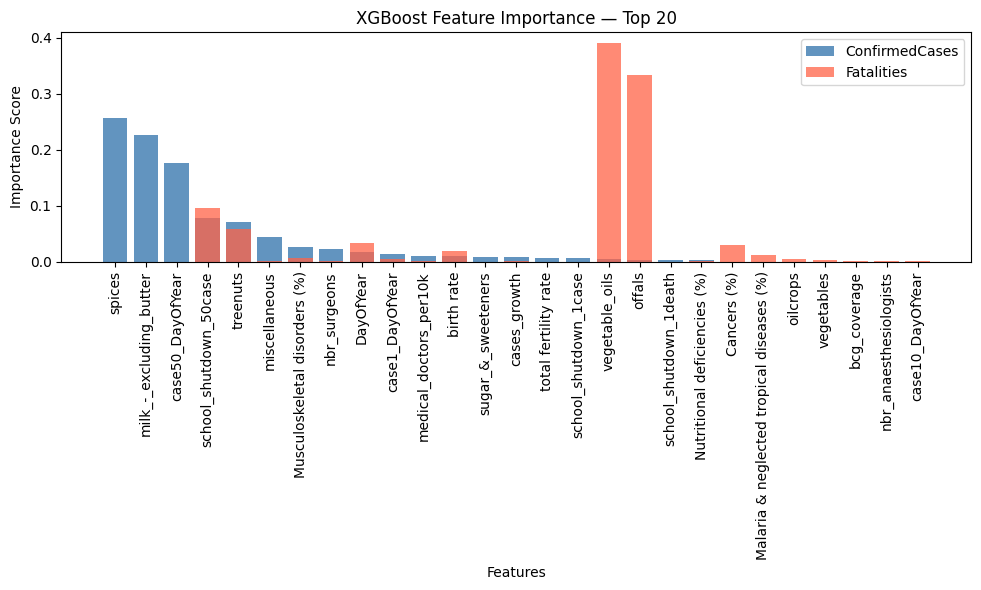

In [34]:
# Bar chart: Top-20 features for each target
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(importances['feature_ConfirmedCases'][:20],
       importances['importance_ConfirmedCases'][:20].astype(float),
       label='ConfirmedCases', alpha=0.85, color='steelblue')

ax.bar(importances['feature_Fatalities'][:20],
       importances['importance_Fatalities'][:20].astype(float),
       label='Fatalities', alpha=0.75, color='tomato')

ax.set_xlabel('Features')
ax.set_ylabel('Importance Score')
ax.set_title('XGBoost Feature Importance — Top 20')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 6. Conclusions

The model confirms our hypothesis partially:

- **COVID-specific features** (hospital density, case growth, beds per 10K, death growth) logically rank highly for predicting both targets.
- **Unexpected top features:** `milk_-_excluding_butter`, `diabetes`, `blood & endocrine diseases`, and `vegetable_oil` appear with surprisingly high importance.
- **Expected low-importance features** like `medical_doctors_per10k` and `school_shutdown_50cases` do appear lower in the ranking.

This underscores how XGBoost can surface non-obvious correlates in high-dimensional health data, though correlation does not imply causation.


In [35]:
# Final RMSLE summary
print("=" * 45)
print(f"  ConfirmedCases  RMSLE : {rmsle(train['ConfirmedCases'], train['yhat_xgb_ConfirmedCases']):.6f}")
print(f"  Fatalities      RMSLE : {rmsle(train['Fatalities'],     train['yhat_xgb_Fatalities']):.6f}")
print("=" * 45)

print("\nSample predictions:")
print(train[['Country_Region', 'ConfirmedCases', 'yhat_xgb_ConfirmedCases']].head(10).to_string(index=False))


  ConfirmedCases  RMSLE : 2.841936
  Fatalities      RMSLE : 1.643996

Sample predictions:
Country_Region  ConfirmedCases  yhat_xgb_ConfirmedCases
   Afghanistan             0.0                 0.011513
   Afghanistan             0.0                 0.011513
   Afghanistan             0.0                 0.136012
   Afghanistan             0.0                 0.136012
   Afghanistan             0.0                 0.136012
   Afghanistan             0.0                 0.136012
   Afghanistan             0.0                 0.100743
   Afghanistan             0.0                 0.100743
   Afghanistan             0.0                 0.100743
   Afghanistan             0.0                 0.100743


## 7. Predict on Test Set

In [36]:
# Load & preprocess test data
test_raw = pd.read_csv('test.csv')

test_raw['Country_Region'] = np.where(
    test_raw['Province_State'].isna(),
    test_raw['Country_Region'],
    test_raw['Country_Region'] + '_' + test_raw['Province_State']
)
test_raw.drop(columns='Province_State', inplace=True)

if 'DayOfYear' not in test_raw.columns:
    test_raw['DayOfYear'] = pd.to_datetime(test_raw['Date']).dt.dayofyear

test_raw['Date'] = pd.to_datetime(test_raw['Date']).dt.date

test = pd.merge(test_raw, health_df, on='Country_Region', how='left')


In [37]:
# Predict
test.drop(columns=['ForecastId', 'Date'], inplace=True)

test['yhat_xgb_ConfirmedCases'] = xgb_confirmed.predict(test[feature_cols].to_numpy())
test['yhat_xgb_Fatalities']     = xgb_fatalities.predict(test[feature_cols].to_numpy())

print("Test predictions (sample):")
print(test[['Country_Region', 'yhat_xgb_ConfirmedCases', 'yhat_xgb_Fatalities']].head(15).to_string(index=False))


Test predictions (sample):
Country_Region  yhat_xgb_ConfirmedCases  yhat_xgb_Fatalities
   Afghanistan                97.408569             2.555944
   Afghanistan               109.964012             2.810949
   Afghanistan               122.613472             4.104421
   Afghanistan               137.382172             4.227641
   Afghanistan               167.594559             3.666415
   Afghanistan               173.874649             2.097055
   Afghanistan               224.339722             0.330624
   Afghanistan               260.710144             7.403830
   Afghanistan               275.322784             9.602635
   Afghanistan               303.457123             7.332202
   Afghanistan               348.845001             6.997285
   Afghanistan               380.255707            11.051382
   Afghanistan               420.936371            13.840384
   Afghanistan               420.936371            13.840384
   Afghanistan               420.936371            13.8403

In [38]:
test[['yhat_xgb_ConfirmedCases', 'Country_Region']]


,yhat_xgb_ConfirmedCases,Country_Region
0,97.408569,Afghanistan
1,109.964012,Afghanistan
2,122.613472,Afghanistan
3,137.382172,Afghanistan
4,167.594559,Afghanistan
...,...,...
13153,10.890722,Zimbabwe
13154,10.890722,Zimbabwe
13155,10.890722,Zimbabwe
13156,10.890722,Zimbabwe
